In [13]:
import pandas as pd
import re

# Load the dataset
df = pd.read_csv("../data/raw/realdonaldtrump.csv")

# Define a robust text cleaning function
def clean_tweet(text):
    # Handle any missing values by returning an empty string
    if not isinstance(text, str):
        return ""

    # Lowercase the text
    text = text.lower()

    # Remove URLs (http, https, www)
    text = re.sub(r'http\S+|www\.\S+', '', text)

    # Remove user mentions (e.g., @realdonaldtrump)
    text = re.sub(r'@\w+', '', text)

    # Remove special characters, numbers, and emojis
    # (Keeps only standard English alphabetical characters and spaces)
    text = re.sub(r'[^a-z\s]', ' ', text)

    # Remove extra whitespaces that might have appeared after removing words
    text = re.sub(r'\s+', ' ', text).strip()

    return text

print("TEXT CLEANING IN PROGRESS")

# Apply the function to create a NEW column
# We keep the original 'content' column safe
df['cleaned_content'] = df['content'].apply(clean_tweet)

# Display the results to compare original text with the cleaned version
print("Original vs Cleaned Tweets (First 5 rows):")
# Use pandas display functionality to show it nicely in Jupyter
display(df[['content', 'cleaned_content']].head())

TEXT CLEANING IN PROGRESS
Original vs Cleaned Tweets (First 5 rows):


,content,cleaned_content
0,Be sure to tune in and watch Donald Trump on L...,be sure to tune in and watch donald trump on l...
1,Donald Trump will be appearing on The View tom...,donald trump will be appearing on the view tom...
2,Donald Trump reads Top Ten Financial Tips on L...,donald trump reads top ten financial tips on l...
3,New Blog Post: Celebrity Apprentice Finale and...,new blog post celebrity apprentice finale and ...
4,"""My persona will never be that of a wallflower...",my persona will never be that of a wallflower ...


In [14]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Download required NLTK datasets
# 'punkt' is for tokenization, 'wordnet' for lemmatization
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

# Initialize the tools
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Define the NLP processing function
def process_nlp(text):
    # Fallback for empty values
    if not text or not isinstance(text, str):
        return ""

    # A. Tokenization: Split text into a list of individual words
    tokens = word_tokenize(text)

    # B. Stopwords removal & C. Lemmatization
    # We also remove words that are just 1 character long (e.g., isolated 's' or 't')
    processed_tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words and len(word) > 1
    ]

    # D. Rejoin into a single string
    # (Models like TF-IDF require string format, not lists)
    return " ".join(processed_tokens)

print("NLP PROCESSING IN PROGRESS")

# Apply the function to create the final processed column
df['processed_content'] = df['cleaned_content'].apply(process_nlp)

# Handle missing data in other columns (Crucial for Feature Engineering)
# We fill NaN values in 'hashtags' and 'mentions' with empty strings
df['hashtags'] = df['hashtags'].fillna("")
df['mentions'] = df['mentions'].fillna("")

# Display the full transformation pipeline
print("Pipeline Check (Original -> Cleaned -> Processed):")
display(df[['content', 'cleaned_content', 'processed_content']].head())

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\alicj\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\alicj\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\alicj\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\alicj\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


NLP PROCESSING IN PROGRESS
Pipeline Check (Original -> Cleaned -> Processed):


,content,cleaned_content,processed_content
0,Be sure to tune in and watch Donald Trump on L...,be sure to tune in and watch donald trump on l...,sure tune watch donald trump late night david ...
1,Donald Trump will be appearing on The View tom...,donald trump will be appearing on the view tom...,donald trump appearing view tomorrow morning d...
2,Donald Trump reads Top Ten Financial Tips on L...,donald trump reads top ten financial tips on l...,donald trump read top ten financial tip late s...
3,New Blog Post: Celebrity Apprentice Finale and...,new blog post celebrity apprentice finale and ...,new blog post celebrity apprentice finale less...
4,"""My persona will never be that of a wallflower...",my persona will never be that of a wallflower ...,persona never wallflower rather build wall cli...


In [19]:
import os
import numpy as np

print("ADDING BONUS FEATURES & EXPORTING CLEANED DATASET")

# Add the tweet length based on the original 'content' column
df['tweet_length'] = df['content'].astype(str).apply(len)

# Calculate the 33rd and 67th percentiles for 'retweets'
p33 = df['retweets'].quantile(0.3333)
p67 = df['retweets'].quantile(0.6667)

# Create a new column 'engagement_level' based on these thresholds
def categorize_engagement(retweets):
    if retweets <= p33:
        return 'Low'
    elif retweets <= p67:
        return 'Medium'
    else:
        return 'High'

df['engagement_level'] = df['retweets'].apply(categorize_engagement)

# Define the directory and filename
output_dir = '../data/processed'
output_filename = 'cleaned_realdonaldtrump.csv'

# Create the directory if it doesn't exist
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"Directory created: {output_dir}")

# Save the dataframe to the specified path
full_path = os.path.join(output_dir, output_filename)
df.to_csv(full_path, index=False)

# Confirm the file was saved and check its size
file_size_mb = os.path.getsize(full_path) / (1024 * 1024)
print(f"Success! Dataset saved at: {full_path}")
print(f"File size: {file_size_mb:.2f} MB")
print("New column 'tweet_length' was added successfully!")

ADDING BONUS FEATURES & EXPORTING CLEANED DATASET
Success! Dataset saved at: ../data/processed\cleaned_realdonaldtrump.csv
File size: 19.20 MB
New column 'tweet_length' was added successfully!


GENERATING WORDCLOUD


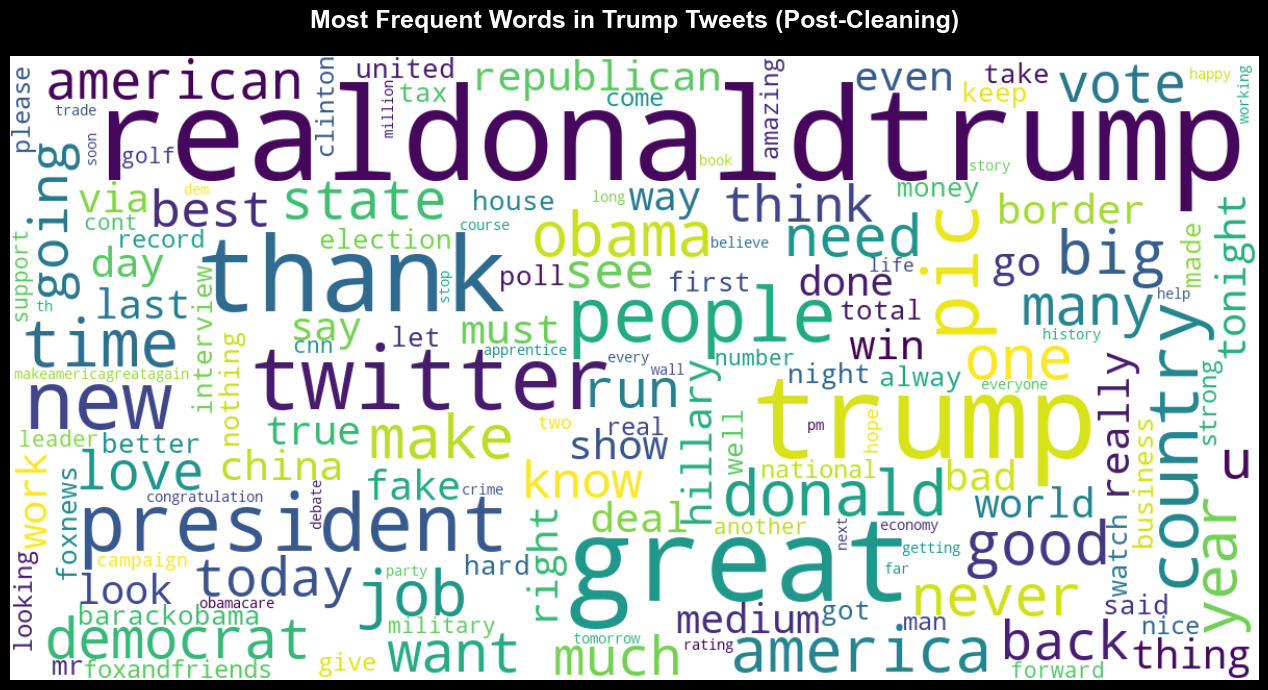

In [20]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

print("GENERATING WORDCLOUD")

# Combine all processed tweets into one massive string
# We use 'processed_content' because it is already free of stopwords, links, and punctuation
all_words = ' '.join(text for text in df['processed_content'] if isinstance(text, str))

# Configure and generate the WordCloud
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    colormap='viridis',  # 'viridis' or 'plasma' look very professional
    max_words=150,       # Display the top 150 most frequent words
    collocations=False   # Avoids duplicating word pairs like "fake news" if they appear often
).generate(all_words)

# Plot the WordCloud
plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # Turn off the axes for a cleaner look
plt.title('Most Frequent Words in Trump Tweets (Post-Cleaning)', fontsize=18, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [21]:
from collections import Counter

# Combine all processed tweets into a list of words
# We skip empty strings to be clean
all_words = ' '.join(df['processed_content'].fillna("").astype(str)).split()

# Count the frequencies
word_counts = Counter(all_words)

# Get the top 20 most frequent words
top_20 = word_counts.most_common(20)

print("TOP 20 MOST FREQUENT WORDS")
for word, count in top_20:
    print(f"{word}: {count}")

TOP 20 MOST FREQUENT WORDS
realdonaldtrump: 8637
great: 6766
trump: 6723
twitter: 3697
com: 3541
thank: 3060
president: 3050
pic: 2877
people: 2727
thanks: 2337
country: 2315
get: 2160
time: 2070
would: 2008
new: 1961
america: 1887
donald: 1885
job: 1856
like: 1788
obama: 1778
